# <b>Classification par régression logistique, Analyse discriminante linéaire (LDA) et quadratique (QDA)</b>
## pour plus de détails voir le livre de James, Witten, Hastie, Tibshirani, deuxième édition



In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import norm

In [5]:
default = pd.read_csv('../data/default.csv')
default.head()


,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


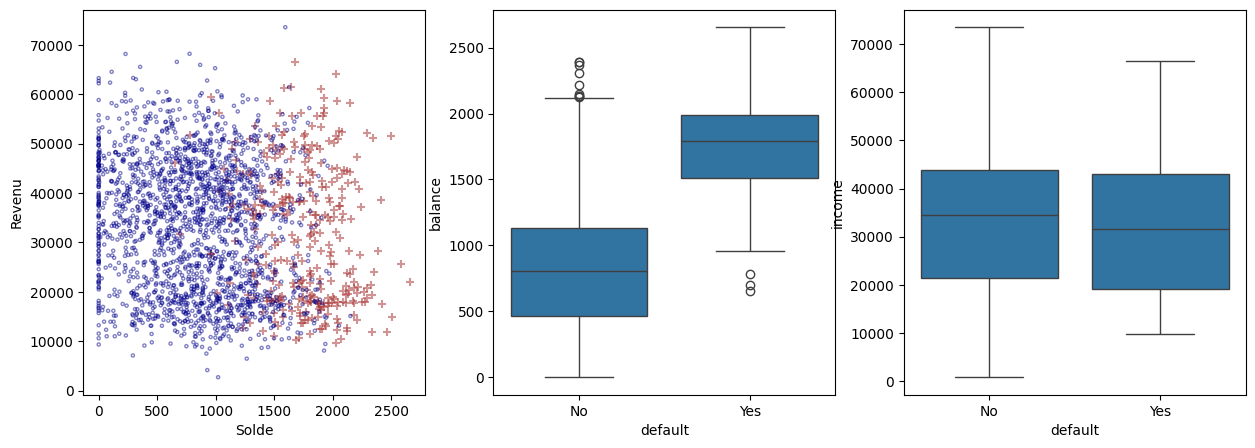

In [6]:
fig,axs = plt.subplots(1,3,figsize = (15,5))
defaulted = default[default['default']=='Yes']
notdef = default[default['default']=='No']
plt.subplot(1,3,1)
plt.scatter(defaulted['balance'],defaulted['income'],marker ='+',color='brown',alpha=0.5)
plt.scatter(notdef['balance'][::5],notdef['income'][::5],facecolor='None',edgecolor='darkblue',alpha=0.5,s=5)
plt.xlabel('Solde')
plt.ylabel('Revenu');

plt.subplot(1,3,2)
sns.boxplot(x='default',y='balance',data=default)
sns.set(rc = {'figure.figsize':(5,5)})

plt.subplot(1,3,3)
sns.boxplot(x='default',y='income',data=default)
sns.set(rc = {'figure.figsize':(5,5)})


### La régression logistique:

La régression logistique modélise la probabilité que la réponse (catégorielle binaire) $Y$ appartienne à une certaine catégorie. Pour les données ci-dessus : P(défaut = 'Oui' | solde) = p(solde). La prédiction par défaut = Oui avec le seuil 0.5 (p(solde) >0.5), pour certains usages (par exemple, accorder un prêt), un seuil plus bas (0.2) ou plus grand (0.8) peut être choisi.

Le modèle de régression logistique produit une sortie pouvant prendre des valeurs entre 0 et 1 pour toutes les valeurs d'entrée. La fonction utilisée est la suivante :

$$ p(X) = \frac{e^{\beta_0 +\beta_1 X}}{1+e^{\beta_0 + \beta_1X}}$$

Cette méthode peut être utilisée lorsque la sortie se situe entre deux décisions pour toutes les valeurs d'entrée. La quantité $ \frac{p(X)}{1-p(X)} = e^{\beta_0 +\beta_1 X}$ est appelée cotes (odds), dans la plage $[0,\infty]$. 0/$\infty$ indique une probabilité de défaut très faible/élevée.

Les cotes logarithmiques, ou logit, sont obtenues en prenant le logarithme des cotes.

$$ \log{\frac{p(X)}{1-p(X)}} = \beta_0 +\beta_1 X $$

et est linéaire en X. Augmenter X d'une unité correspond à un changement de log cotes par $\beta_1$.

Les coefficients $\beta_0, \beta_1$ sont inconnus et doivent être estimés à partir des données d'entraînement. Les moindres carrés peuvent être utilisés, mais la vraisemblance maximale est généralement préférée en raison de ses propriétés statistiques favorables. La fonction de vraisemblance est la suivante :

$$ l(\beta_0,\beta_1) = \prod_{i:y_i=1} p(x_i) \prod_{i':y_{i'}=0} (1-p(x_{i'})) $$

et les estimations des coefficients sont faites de manière à maximiser la fonction de vraisemblance $l$.




###  Comparaison entre la régression linéaire et la logistique

/tmp/ipykernel_130081/652690128.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  y = default[['default']].applymap(lambda x: yndict[x])
/home/layedev/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


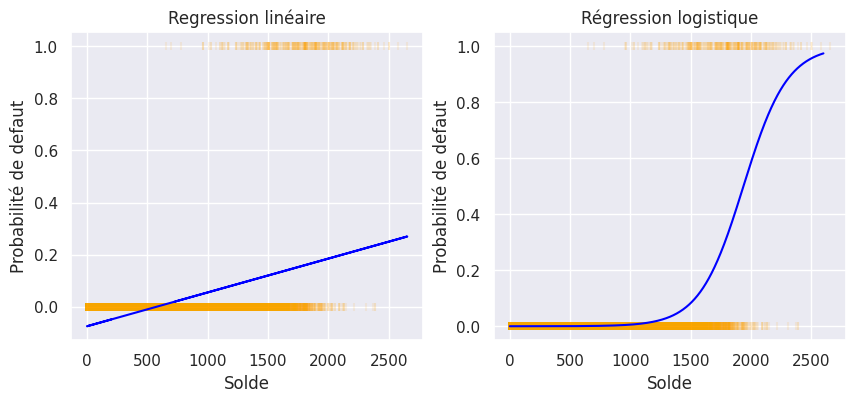

In [8]:
from sklearn.linear_model import LinearRegression
yndict = {'Yes':1,'No':0}
regress = LinearRegression()
X = default[['balance']]
y = default[['default']].applymap(lambda x: yndict[x])
regress = LinearRegression()
regress.fit(X,y)
y_pred = regress.predict(X)

plt.subplots(1,2,figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(X,y,marker='|',c='orange',alpha=0.1)
plt.plot(X,y_pred,color = 'blue')
plt.xlabel('Solde')
plt.ylabel('Probabilité de defaut')
plt.title('Regression linéaire')

from sklearn.linear_model import LogisticRegression

xlin = np.linspace(0,2600,1000)
logreg = LogisticRegression(random_state=0)
logreg.fit(X,np.ravel(y))
y_predlog = logreg.predict_proba(xlin[:,np.newaxis])

plt.subplot(1,2,2)
plt.scatter(X,y,marker='|',c='orange',alpha=0.1)
plt.plot(xlin,y_predlog[:,1],color = 'blue')
plt.xlabel('Solde')
plt.ylabel('Probabilité de defaut')
plt.title('Régression logistique');

####  Appliquons la régression logistique aux données ci-dessus

In [ ]:
# On définit une fonction qui donne les sorties de la régression logistique, coefficients estimés
# par maximum de vraissemblance, erreur standard, statistique de test, p-value


from scipy.stats import t

def logitstatvals(X,y,sigfig):

    logreg = LogisticRegression(random_state=0)
    logreg.fit(X,np.ravel(y))
    y_pred = logreg.predict_proba(X)
    inter = logreg.intercept_
    coeffs = logreg.coef_
    coeffs = coeffs.T

    X_design = np.hstack([np.ones((X.shape[0], 1)), X])
    V = np.diagflat(np.prod(y_pred,axis = 1)) 
    # matrice de variance-covariance des erreurs
    covar = np.linalg.inv(X_design.T @ V @ X_design)

    sterrs = np.sqrt(np.diag(covar))

    z_b0 = inter/sterrs[0]
    z_b1 = coeffs.T/sterrs[1:]
    z_b1 = z_b1.T

    dof = np.shape(X)[0]-2
    pval_0 = 2*(1 - t.cdf(abs(z_b0), dof))
    pval_1 = 2*(1 - t.cdf(abs(z_b1), dof))
    pval_1 = np.array(pval_1)

    d = {0: ["Intercept", inter, sterrs[0], z_b0, pval_0]}
    for i in range(0,len(sterrs)-1):
        d[i+1] = [X.columns[i], coeffs[i], sterrs[1+i],z_b1[i],pval_1[i]]
    print ("{:<12} {:<12} {:<12} {:<12} {:<12}".format("Parameter",'Coefficient','Std. Error','z-statistic','p-value'))
    for k, v in d.items():
        name, coef,std,tstat,pval = v
        print ("{:<12} {:<12} {:<12} {:<12} {:<12}".format(name,round(float(coef),sigfig),round(float(std),sigfig),round(float(tstat),sigfig),round(float(pval),sigfig)))


In [10]:
X = default[['balance']]
yndict = {'Yes':1,'No':0}
y = default[['default']].applymap(lambda x: yndict[x])

logitstatvals(X,y,5)

/tmp/ipykernel_130081/2780803584.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  y = default[['default']].applymap(lambda x: yndict[x])


Parameter    Coefficient  Std. Error   z-statistic  p-value     
Intercept    -10.65133    0.36117      -29.49129    0.0         
balance      0.0055       0.00022      24.95241     0.0         


/tmp/ipykernel_130081/4246930265.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ("{:<12} {:<12} {:<12} {:<12} {:<12}".format(name,round(float(coef),sigfig),round(float(std),sigfig),round(float(tstat),sigfig),round(float(pval),sigfig)))


La statistique de test $z-\hat \beta_1 / SE(\hat \beta_1)$ est analogue à celle $t$ de la régression linéaire. Une grande statistique $z$ constitue une preuve solide contre l'hypothèse nulle de nullité du coefficient.



In [11]:
yndict = {'Yes':1,'No':0}
X = default[['student']].applymap(lambda x: yndict[x])
y = default[['default']].applymap(lambda x: yndict[x])
logitstatvals(X,y,4)

/tmp/ipykernel_130081/1080161166.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = default[['student']].applymap(lambda x: yndict[x])
/tmp/ipykernel_130081/1080161166.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  y = default[['default']].applymap(lambda x: yndict[x])


Parameter    Coefficient  Std. Error   z-statistic  p-value     
Intercept    -3.5026      0.0707       -49.5684     0.0         
student      0.3962       0.1152       3.4387       0.0006      


/tmp/ipykernel_130081/4246930265.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ("{:<12} {:<12} {:<12} {:<12} {:<12}".format(name,round(float(coef),sigfig),round(float(std),sigfig),round(float(tstat),sigfig),round(float(pval),sigfig)))


#### Régression logistique avec plusieurs instances

In [12]:
yndict = {'Yes':1,'No':0}
y = default[['default']].applymap(lambda x: yndict[x])
x1 = default[['balance']]
x2 = default[['income']]
x3 = default[['student']].applymap(lambda x: yndict[x])
X = pd.concat([x1,x2,x3],axis=1)
pval = logitstatvals(X,y,4)

/tmp/ipykernel_130081/3881352878.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  y = default[['default']].applymap(lambda x: yndict[x])
/tmp/ipykernel_130081/3881352878.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x3 = default[['student']].applymap(lambda x: yndict[x])


Parameter    Coefficient  Std. Error   z-statistic  p-value     
Intercept    -10.9018     0.4932       -22.1061     0.0         
balance      0.0057       0.0002       24.7355      0.0         
income       0.0          0.0          0.4827       0.6293      
student      -0.6126      0.2364       -2.5913      0.0096      


/tmp/ipykernel_130081/4246930265.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ("{:<12} {:<12} {:<12} {:<12} {:<12}".format(name,round(float(coef),sigfig),round(float(std),sigfig),round(float(tstat),sigfig),round(float(pval),sigfig)))


Examinons si le fait qu'une personne soit étudiante influence sa probabilité de défaut par rapport à un non-étudiant, étant donné qu'ils ont le même solde de carte de crédit.

/tmp/ipykernel_130081/936293279.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  yyes = datayes[['default']].applymap(lambda x: yndict[x])
/tmp/ipykernel_130081/936293279.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  yno = datano[['default']].applymap(lambda x: yndict[x])


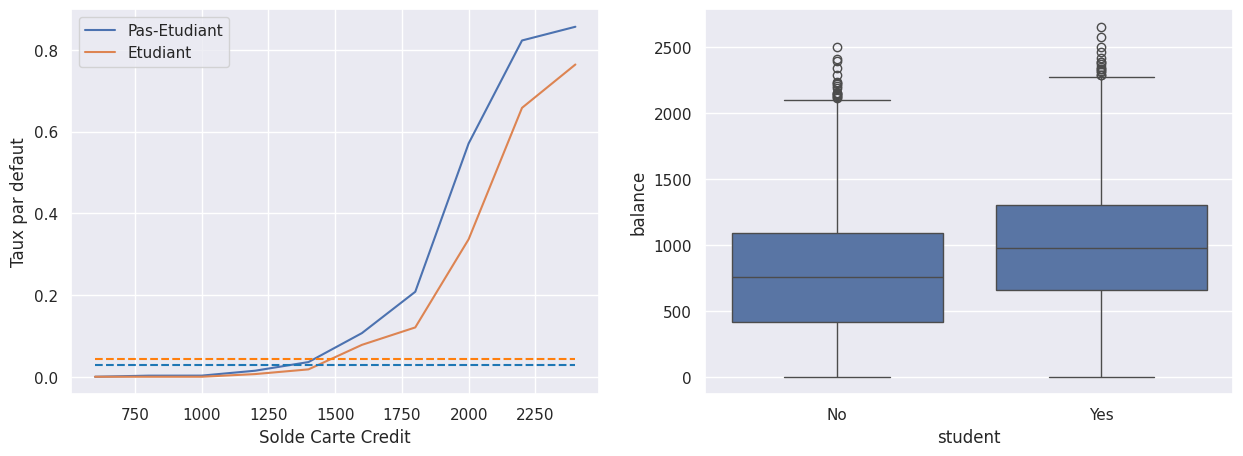

In [14]:
datayes = default[default['student']=='Yes']
datano = default[default['student']=='No']
xes = np.linspace(400,2400,11)
yyes = datayes[['default']].applymap(lambda x: yndict[x])
yno = datano[['default']].applymap(lambda x: yndict[x])

aveyes = []
aveno = []
for i in range(0,len(xes)-1):
    aveyes.append(np.mean(yyes[(datayes['balance']>xes[i]) & (datayes['balance']<xes[i+1])]))
    aveno.append(np.mean(yno[(datano['balance']>xes[i]) & (datano['balance']<xes[i+1])]))

fig,axs = plt.subplots(1,2,figsize = (15,5))
plt.subplot(1,2,1)
plt.plot(xes[1:],aveno,label='Pas-Etudiant')
plt.plot(xes[1:],aveyes,label = 'Etudiant')
plt.xlabel('Solde Carte Credit')
plt.ylabel('Taux par defaut')
plt.legend()
plt.plot(xes[1:], np.mean(yno) * np.ones(len(xes[1:])), color='tab:blue', linestyle='--')
plt.plot(xes[1:], np.mean(yyes) * np.ones(len(xes[1:])), color='tab:orange', linestyle='--')
plt.subplot(1,2,2)
sns.boxplot(x='student',y='balance',data=default);

In [23]:
np.mean(yno)

np.float64(0.02919501133786848)

Etant donné un solde de carte de crédit, les étudiants sont moins susceptibles de faire défaut que les non-étudiants. En général, les étudiants ont des soldes plus élevés, cependant, et donc leur taux de défaut est également plus élevé en moyenne.

#### Régression logistique multinomiale

La régression logistique à deux classes peut être étendue à $K>2$ classes en utilisant la régression logistique multinomiale. Pour effectuer ce modèle, une classe est sélectionnée comme référence. Le choix de la classe de référence n'affecte pas les résultats : les prédictions, les log odds entre les paires de classes et d'autres modèles clés. Cependant, les estimations des coefficients seront différentes en raison de différentes classes de référence.

Un codage alternatif est le 'softmax'. Dans ce codage, toutes les $K$ classes sont traitées de manière symétrique, au lieu de sélectionner une classe de référence.

#### Modèles additifs

Une approche alternative à la régression logistique est celle des modèles additifs généralisés, où la distribution des prédicteurs est modélisée pour chaque valeur de réponse. En utilisant le théorème de Bayes, les estimations sont inversées pour découvrir la probabilité conditionnelle $P(Y=k|X=x)$.

Cette approche est utile et/ou plus précise (comparée à la régression logistique) lorsque la séparation entre les classes est grande, la distribution des prédicteurs est proche de la normale dans chaque classe, ou le nombre de classes de réponse est plus grand que 2.

Disons que nous avons $K$ classes, alors par le théorème de Bayes,

$$ P(Y=k|X=x) = \frac{P(X=x|Y=k) \cdot P(Y=k)}{P(X=x)} $$

ou dans une notation équivalente,

$$ p_k(x) = \frac{P(X=x|Y=k) \cdot P(Y=k)}{\sum_{l=1}^K P(X=x|Y=l) \cdot P(Y=l)} $$

Si $f_k(x) = P(X=x|Y=k)$ est connu, le classificateur de Bayes peut être utilisé (taux d'erreur minimum). Il existe plusieurs méthodes pour estimer cette valeur. Les suivantes seront discutées : l'analyse discriminante linéaire, l'analyse discriminante quadratique et le naïf de Bayes.

#### L'analyse discriminante linéaire LDA

Supposons que nous ayons un seul prédicteur. Nous supposons que $f_k(x)$ est normale, ce qui donne pour une dimension,

$$f_k(x) = \frac{1}{\sqrt{2 \pi} \sigma_k} e^{-\frac{1}{2\sigma^2_k}(x-\mu_k)^2}. $$

Supposons que toutes les variances soient égales ($\sigma_i =\sigma,$    $\forall i$) et en notant $\pi_k \equiv P(Y=k),$

$$ p_k(x) = \frac{ \pi_k \frac{1}{\sqrt{2 \pi} \sigma} e^{-\frac{1}{2\sigma^2}(x-\mu_k)^2}}{\sum_{l=1}^K \pi_l \frac{1}{\sqrt{2 \pi} \sigma} e^{-\frac{1}{2\sigma^2}(x-\mu_l)^2}}. $$

En prenant le logarithme de l'équation ci-dessus, le classificateur de Bayes attribue l'observation à la classe pour laquelle l'équation ci-dessous est maximisée :

$$\delta_k(x) = x \frac{\mu_k}{\sigma^2}-\frac{\mu_k^2}{2\sigma^2} + \log(\pi_k). $$

(Pour la fonction discriminante linéaire, l'estimation $\hat \delta_k(x)$ est une fonction linéaire de $x$.)

Pour deux classes avec une probabilité égale, la frontière de décision de Bayes prend une équation simple $x =\frac{\mu_1+\mu_2}{2}.$

Dans les graphiques ci-dessous, deux distributions normales sont représentées avec des moyennes $\mu = \pm 1.25$.

20 échantillons sont tirés de chaque distribution, affichés à droite. La frontière de décision de Bayes est représentée par une ligne en pointillés et la frontière d'analyse discriminante linéaire (à partir des échantillons) par une ligne continue.

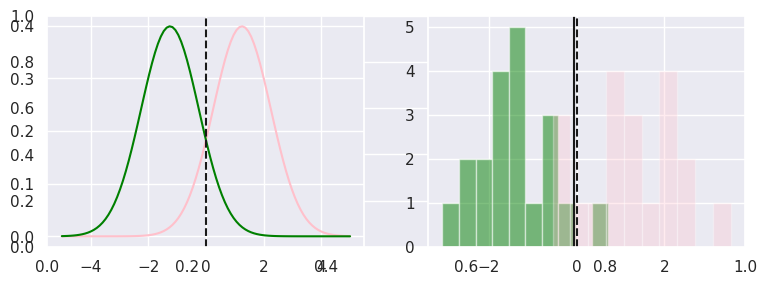

In [15]:
mu_1 = 1.25
mu_2 = -1.25
var = 1
x = np.linspace(-5, 5, 100)

#Plot distributions normales
fig = plt.subplots(figsize=(9,3))
plt.subplot(1,2,1)
plt.plot(x,stats.norm.pdf(x,mu_1,var),c='pink')
plt.plot(x,stats.norm.pdf(x,mu_2,var),c='green')
plt.axvline(x=0,c='k',linestyle='--')

left_pts = np.random.normal(mu_2,var,20)
right_pts = np.random.normal(mu_1,var,20)
left_class = np.zeros(len(left_pts))
right_class = np.ones(len(right_pts))
all_pts = np.array([*left_pts , *right_pts])
all_class = np.array([*left_class,*right_class])


#LDA -- frontiere de decision
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(all_pts.reshape(-1, 1),all_class)
probs = lda.predict(x.reshape(-1,1))
idx = len(probs[probs==0])
decision = x[idx]

#Histogramme des frontieres de decision
plt.subplot(1,2,2)
plt.hist(left_pts,color='green',alpha=0.5)
plt.hist(right_pts,color='pink',alpha=0.3)
plt.axvline(x=0,c='k',linestyle='--')
plt.axvline(x=decision,c='k');


Maintenant, étendons cette analyse à plus d'un prédicteur. Au lieu de X étant une distribution normale, $X=(X_1,X_2,...,X_P)$ est maintenant une distribution normale multivariée. Elle a une moyenne spécifique à la classe et une matrice de covariance commune.

Dans ce cas, la valeur maximale pour

$$\delta_k(x)=x^T \Sigma^{-1} \mu_k - \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \log \pi_k $$

détermine à quelle classe l'observation $X=x$ est assignée par le classificateur de Bayes, où $\Sigma$ représente la matrice de covariance commune.

La frontière de décision est définie par le point où $\delta_k(x) = \delta_l(x)$, ainsi,

$$x^T \Sigma^{-1} \mu_k -\frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k = x^T \Sigma^{-1} \mu_l -\frac{1}{2} \mu_l^T \Sigma^{-1} \mu_l $$

pour des observations d'entraînement égales, c'est-à-dire pour des $\pi_k$ égaux.

In [16]:
from scipy import linalg
from matplotlib import colors
from matplotlib.patches import Ellipse

#Ellipses
mu_1 = [-0.75,-0.75]
mu_2 = [1,2]
mu_3 = [2,1]
cov =  [[1.33,0.67],[0.67,1.33]]

#Valeurs et vecteur propres
v, w = linalg.eigh(cov)
theta = np.linspace(0,2*np.pi,1000)
el_1 = (np.sqrt(v[None,:])*w) @[np.sin(theta),np.cos(theta)]

#Bayes frontiere de decision
center = [(mu_1[0]+mu_2[0]+mu_3[0])/3, (mu_1[1]+mu_2[1]+mu_3[1])/3]

invcov = linalg.inv(cov)
mu_1 = np.array(mu_1)
mu_2 = np.array(mu_2)
mu_3 = np.array(mu_3)
x12 = (1/2)*(mu_1.T*invcov*mu_1-mu_2.T*invcov*mu_2)*linalg.inv(invcov*mu_1-invcov*mu_2)
x13 = (1/2)*(mu_1.T*invcov*mu_1-mu_3.T*invcov*mu_3)*linalg.inv(invcov*mu_1-invcov*mu_3)
x23 = (1/2)*(mu_2.T*invcov*mu_2-mu_3.T*invcov*mu_3)*linalg.inv(invcov*mu_2-invcov*mu_3)


x1 = np.linspace(-3,center[0],10)
y1 = -(x1-center[0])*x12[0,0]/x12[1,1] + center[1]
x2 = np.linspace(center[0],4.2,10)
y2 = (x2-center[0])*x23[0,0]/x23[1,1] + center[1]
y3 = np.linspace(center[1],-3,10)
x3 = -(y3-center[1])*x13[1,1]/x13[0,0] + center[0]

In [17]:
#Un echantillon aleatoire

pts0 = np.random.multivariate_normal(mu_1,cov,20)
pts1 = np.random.multivariate_normal(mu_2,cov,20)
pts2 = np.random.multivariate_normal(mu_3,cov,20)
class0 = np.zeros(len(pts0))
class1 = np.ones(len(pts1))
class2 = np.ones(len(pts2))*2
all_pts = np.array([*pts0, *pts1 , *pts2])
all_class = np.array([*class0,*class1,*class2])

#LDA

gridx,gridy = np.meshgrid(np.linspace(-3,4,100),np.linspace(-3,4,100))
lda.fit(all_pts,all_class)
classification = lda.predict(np.c_[gridx.ravel(),gridy.ravel()])
classification = classification.reshape(gridx.shape)


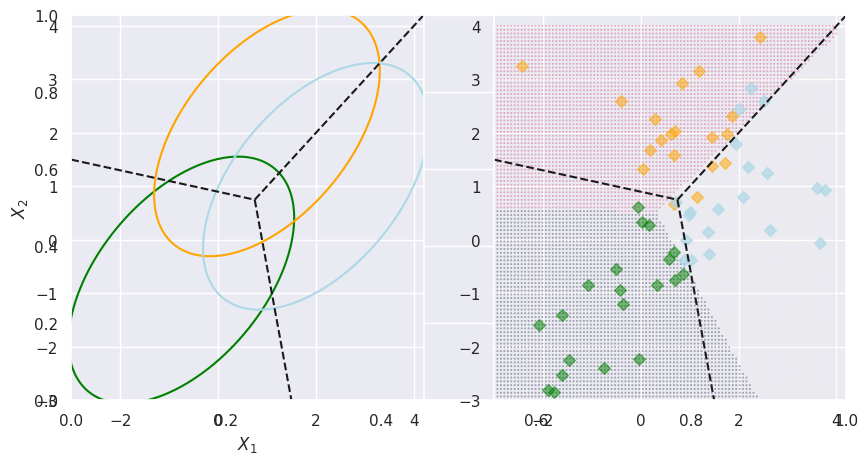

In [18]:
#Plot
fig,ax = plt.subplots(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(2*el_1[0,:]+np.ones(1000,)*mu_1[0],2*el_1[1,:]+np.ones(1000,)*mu_1[1],c='green')
plt.plot(2*el_1[0,:]+np.ones(1000,)*mu_2[0],2*el_1[1,:]+np.ones(1000,)*mu_2[1],c='orange')
plt.plot(2*el_1[0,:]+np.ones(1000,)*mu_3[0],2*el_1[1,:]+np.ones(1000,)*mu_3[1],c='lightblue')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.xlim(-3,4.2)
plt.ylim(-3,4.2)
plt.plot(x2,y2,c='k',linestyle = '--')
plt.plot(x3,y3,c='k',linestyle = '--')
plt.plot(x1,y1,c='k',linestyle = '--')

plt.subplot(1,2,2)
plt.scatter(gridx,gridy,c=classification,alpha=0.5,s=0.1)
plt.scatter(pts0[:,0],pts0[:,1],c='green',marker='D',alpha=0.5)
plt.scatter(pts1[:,0],pts1[:,1],c='orange',marker='D',alpha=0.5)
plt.scatter(pts2[:,0],pts2[:,1],c='lightblue',marker='D',alpha=0.7)
plt.plot(x2,y2,c='k',linestyle = '--')
plt.plot(x3,y3,c='k',linestyle = '--')
plt.plot(x1,y1,c='k',linestyle = '--')
plt.xlim(-3,4.2)
plt.ylim(-3,4.2);


Dans les graphiques ci-dessus, trois classes d'ensembles distribués normalement sont visualisées. 20 observations sont faites pour chaque classe, qui sont représentées sur le graphique de droite. La frontière de décision de Bayes (ligne en pointillés) et les classifications de l'Analyse Discriminante Linéaire (régions ombragées) sont affichées. Notez que la frontière de décision de l'ADL est une fonction linéaire de x.

Maintenant, utilisons cette méthode sur les données de Défaut que nous avons utilisées précédemment dans ce chapitre avec la régression logistique.

Nous pouvons calculer la matrice de confusion pour cette approche, qui nous informe sur les affectations correctes et incorrectes que la méthode de régression fait dans toutes les classes (2, dans le cas des données de Défaut : soit défaut, soit non défaut).

In [32]:
x1 = default[['balance']]
x2 = default[['student']].applymap(lambda x: yndict[x])
X = pd.concat([x1,x2],axis=1)
y = default[['default']].applymap(lambda x: yndict[x])


/tmp/ipykernel_16647/412438305.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x2 = default[['student']].applymap(lambda x: yndict[x])
/tmp/ipykernel_16647/412438305.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  y = default[['default']].applymap(lambda x: yndict[x])


In [20]:
lda.fit(X,y['default'])
default_status = lda.predict(X)

from sklearn.metrics import confusion_matrix, classification_report
conf = confusion_matrix(y['default'],default_status)
print('Confusion matrix:')
print(conf)


Confusion matrix:
[[9645   22]
 [ 254   79]]


Le taux d'erreur global est faible (23+252)/10000, mais le taux d'erreur parmi ceux qui ont fait défaut est incroyablement élevé ! (252/(252+81)), ce qui montre que les performances spécifiques à la classe sont très variables.

Concepts :

-sensibilité : pourcentage de défauts correctement identifiés (24,3%)

-spécificité : pourcentage de non-défauts correctement identifiés (99,8%)

Peut-être que la sensibilité est beaucoup plus importante que la spécificité dans une certaine situation (comme dans le cas de la société de cartes de crédit). Dans ce cas, nous pouvons ajuster l'LDA. Puisque l'LDA approxime le classificateur de Bayes et, dans le cas de deux classes, attribue 'défaut' pour $P($défaut = 'Oui' $|X=x) >0,5$, nous pouvons abaisser le seuil de sorte qu'il attribue 'Oui' pour une probabilité >0,2.

In [21]:
lda.fit(X,y['default'])
default_prob = lda.predict_proba(X)
thres = 0.2
default_status = default_prob[:,1]
default_status[default_status<thres] = 0
default_status[default_status>thres] = 1

conf = confusion_matrix(y['default'],default_status)
print('Matrice de Confusion pour un seuil de 20%:')
print(conf)


Matrice de Confusion pour un seuil de 20%:
[[9435  232]
 [ 140  193]]


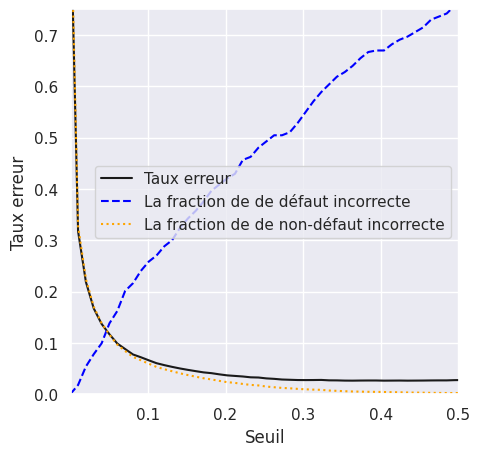

In [22]:
thres = np.linspace(0,1,100)
error_rate = []
incorrect_default = []
incorrect_nondefault = []
correct_default = []

for t in thres:
    lda.fit(X,y['default'])
    default_prob = lda.predict_proba(X)
    default_status = default_prob[:,1]
    default_status[default_status<t] = 0
    default_status[default_status>t] = 1
    conf = confusion_matrix(y['default'],default_status)
    error_rate.append((conf[0,1]+conf[1,0])/10000)
    incorrect_default.append(conf[1,0]/np.sum(conf[1,:]))
    incorrect_nondefault.append(conf[0,1]/np.sum(conf[0,:]))
    correct_default.append(conf[1,1]/np.sum(conf[1,:]))

plt.plot(thres,error_rate,c='k',label='Taux erreur')
plt.plot(thres,incorrect_default,c='blue',linestyle='--',label='La fraction de de défaut incorrecte')
plt.plot(thres,incorrect_nondefault,c='orange',linestyle=':',label='La fraction de de non-défaut incorrecte')
plt.legend()
plt.xlim(0.001,0.5)
plt.ylim(0,0.75)
plt.xlabel('Seuil')
plt.ylabel('Taux erreur');

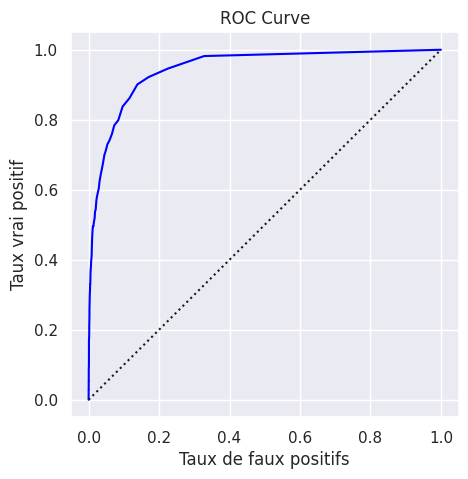

In [23]:
plt.plot(incorrect_nondefault,correct_default,c='blue')
plt.plot(np.linspace(0,1,100),np.linspace(0,1,100),c='k',linestyle=':')
plt.title('ROC Curve')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux vrai positif');

La performance globale d'un classificateur est donnée par l'aire sous la courbe ROC, plus elle est grande, mieux c'est.

In [24]:
xes = np.array(incorrect_nondefault[1:])-np.array(incorrect_nondefault[:-1])
area = np.sum(-xes*np.array(correct_default[:-1]))
print(area)


0.9558511651198109


#### Analyse discriminante quadratique

En QDA, nous relâchons l'hypothèse de covariance égale telle que $X \sim N(\mu_k,\Sigma_k)$. Ainsi, cette méthode étiquette l'observation à la classe pour laquelle l'équation ci-dessous est maximale :

$$ \delta_k(x) = -\frac{1}{2} (x-\mu_k)^T \Sigma_k^{-1}(x-\mu_k)-\frac{1}{2} \log|\Sigma_k|+\log \pi_k $$

Contrairement à LDA, l'équation pour QDA est quadratique en $x$.


#### Bayes naïf

Au lieu de faire des hypothèses sur la distribution de $X$, nous faisons une seule hypothèse d'indépendance : que dans chaque classe, les prédicteurs sont tous indépendants, ce qui signifie que pour chaque classe k

$$ f_k(x) = f_{k_1}(x_1) \times ... \times f_{kp}(x_p), $$

où $f_{kj}$ est la fonction de densité du j-ème prédicteur pour les observations appartenant à la classe k, donc la probabilité a posteriori peut être calculée comme

$$ P(Y=k|X=x)=\frac{\pi_k \times f_{k1}(x_1) \times ... \times f_{kp}(x_p)}{\sum_{l=1}^K \pi_l \times f_{l1}(x_1) \times ... \times f_{lp}(x_p)} $$

Pour estimer $f_{kj}$,
- si $X_j$ est quantitative, $X_j |Y=k \sim N(\mu_{jk},\sigma_{jk}^2)$. (Cela est équivalent au QDA avec une covariance diagonale.) OU utiliser une estimation non paramétrique pour $f_{kj}$ en faisant un histogramme des observations, ou en utilisant un estimateur de densité de noyau.
- si $X_j$ est qualitative, compter la proportion d'observations correspondant à chaque classe.

C'est une bonne méthode pour les cas où n n'est pas trop grand par rapport à p, de sorte que la distribution conjointe ne peut pas être bien estimée.

#### Une comparaison analytique des méthodes de classification discutées

Calcul des log-odds de chaque méthode :

- Analyse Discriminante Linéaire :

$$\log\left(\frac{P(Y=k|X=x)}{P(Y=K|X=x)}\right) = a_k + \sum_{j=1}^p b_{kj}x_j $$

où $a_k = \log\left(\frac{\pi_k}{\pi_K}\right)-\frac{1}{2} (\mu_k+\mu_K)^T \Sigma^{-1}(\mu_k-\mu_K)$ et $b_{kj}$ est la j-ème composante de $\Sigma^{-1}(\mu_k-\mu_K)$.

Ainsi, les log-odds des probabilités a posteriori sont linéaires en x.

- Analyse Discriminante Quadratique :

$$\log\left(\frac{P(Y=k|X=x)}{P(Y=K|X=x)}\right) = a_k + \sum_{j=1}^p b_{kj}x_j + \sum_{j=1}^p \sum_{l=1}^p c_{kjl}x_jx_l. $$

Ainsi, les log-odds des probabilités a posteriori sont quadratiques en x.

- Bayes Naïf :

$$\log\left(\frac{P(Y=k|X=x)}{P(Y=K|X=x)}\right) = a_k + \sum_{j=1}^p g_{kj}(x_j) $$

où $a_k=\log\left(\frac{\pi_k}{\pi_K}\right)$ et $g_{kj}(x_j) = \log\left(\frac{f_{kj}(x_j)}{f_{Kj}(x_j)}\right)$.

Il s'agit donc d'un modèle additif généralisé, les détails seront discutés ultérieurement.

Remarquez que LDA est un cas particulier de QDA avec $c=0$, et les classificateurs avec des frontières de décision linéaires, comme LDA, sont des cas particuliers du Bayes Naïf, où $f_{kj}(x_j) = b_{kj}x_j$. Si le Bayes Naïf est utilisé avec une distribution gaussienne à une dimension pour $f$, alors le Bayes devient un cas particulier de LDA avec $\Sigma$ restreint à une matrice diagonale.

Le Bayes Naïf est un ajustement purement additif, mais QDA inclut des termes multiplicatifs, donc ces deux approches ne sont pas des cas particuliers l'une de l'autre. S'il existe des interactions significatives entre les prédicteurs, QDA peut être plus précis.

Chaque approche a ses forces et devrait être choisie en fonction de la véritable distribution des prédicteurs et des valeurs pour n et p. Utilisez le compromis biais-variance.

- Régression Logistique

$$\log\left(\frac{P(Y=k|X=x)}{P(Y=K|X=x)}\right) = \beta_{k0} + \sum_{j=1}^p\beta_{kj} x_j$$

Même équation que celle de LDA. La différence est que pour LDA, les estimations sont obtenues à partir de prédicteurs suivant une distribution normale dans chaque classe. Pour la régression logistique, les coefficients sont choisis pour maximiser la fonction de vraisemblance. Pour les prédicteurs suivant une distribution approximativement normale, LDA surpassera, et sinon, la régression logistique le fera.

### Exercice: Appliquons ces modèles

On peut rendre binaire la variable bikers et prendre comme covariables, temp, hum, windspeed, weekday, holidays.

In [42]:
bikeshare = pd.read_csv('Bikeshare.csv')
bikeshare = bikeshare.drop(columns = 'Unnamed: 0', axis =1)
bikeshare.head()


,season,mnth,day,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,bikers
0,1,Jan,1,0,0,6,0,clear,0.24,0.2879,0.81,0.0,3,13,16
1,1,Jan,1,1,0,6,0,clear,0.22,0.2727,0.80,0.0,8,32,40
2,1,Jan,1,2,0,6,0,clear,0.22,0.2727,0.80,0.0,5,27,32
3,1,Jan,1,3,0,6,0,clear,0.24,0.2879,0.75,0.0,3,10,13
4,1,Jan,1,4,0,6,0,clear,0.24,0.2879,0.75,0.0,0,1,1


In [44]:
from sklearn import datasets
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=['sepal length','sepal width', 'petal length','petal width'])
y = pd.DataFrame(iris.target, columns=['espece'])